# Landfall DT Testing
This notebook contains code to visualize the landfall DT process. Only the last figure is included in Corrie et al. (2026) but other figures are worth playing around with!

In [2]:
import xarray as xa
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cftime

In [3]:
# Define once here, gets used in several places. Plots landmask and coastal points.
def plot_landmask_and_coast(x, y):
    land = xa.open_dataset('/glade/derecho/scratch/tcorrie/regrids/landmask_regridded.nc')
    coast = xa.where(land['LANDMASK'] >= 0.5, 1, 0).idxmax(dim='lon')
    fig, ax = plt.subplots(figsize=(x, y))
    land.LANDMASK.plot(ax=ax)
    ax.scatter(coast, coast.lat, color='r', s=5)

In [4]:
# tARget output (for some reason) uses some huge negative number and/or nan values in its output. This fixes that.
def set_to_zero(ds):
    ds_nonnan = ds.fillna(0)
    ds_nonnanneg = ds_nonnan.clip(min=0)
    return ds_nonnanneg

In [5]:
wusd3 = pd.read_csv('../wusd3_gcms.csv', index_col=0)
wusd3 = wusd3.drop(index=6).reset_index(drop=True)
wusd3

,Model,Model Name,Member,Calendar
0,access-cm2,ACCESS-CM2,r5i1p1f1,standard
1,canesm5,CanESM5,r1i1p2f1,365_day
2,cesm2,CESM2,r11i1p1f1,365_day
3,cnrm-esm2-1,CNRM-ESM2-1,r1i1p1f2,standard
4,ec-earth3,EC-Earth3,r1i1p1f1,standard
5,ec-earth3-veg,EC-Earth3-Veg,r1i1p1f1,standard
6,fgoals-g3,FGOALS-g3,r1i1p1f1,365_day
7,giss-e2-1-g,GISS-E2-1-G,r1i1p1f2,365_day
8,miroc6,MIROC6,r1i1p1f1,standard
9,mpi-esm1-2-hr,MPI-ESM1-2-HR,r3i1p1f1,standard


In [6]:
# This function plots landfall for one specific timestep and model/ardt configuration.
# Member parameter needed as CESM2-LE has 10 of them.
# Outputs the coastal points with the ARmask and some statistics at the bottom. For testing purposes.

def plot_landfall(tidx, model, member, ardt):
    ARmask = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARmasks/{ardt}/ARmask.{model}.{member}.nc').isel(time=tidx)
    ARmask = set_to_zero(ARmask)
    land = xa.open_dataset('/glade/derecho/scratch/tcorrie/regrids/landmask_regridded.nc')
    coast = xa.where(land['LANDMASK'] >= 0.5, 1, 0).idxmax(dim='lon')
    ARcoast = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/{ardt}/ARcoast.{ardt}.{model}.{member}.nc').isel(time=tidx)
    ARcoast = set_to_zero(ARcoast)
    ARlandfall = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/{ardt}/ARlandfall.{ardt}.{model}.{member}.nc').isel(time=tidx)
    ARlandfall = set_to_zero(ARlandfall)

    def get_coast_coords(min_lat, max_lat):
        coast_subs = coast.sel(lat=slice(min_lat, max_lat))
        coast_lats = coast_subs.lat.data
        coast_lons = coast_subs.data
        return(coast_lons, coast_lats)

    coast_lons_wus, coast_lats_wus = get_coast_coords(32.5,48.51)
    coast_lons_sca, coast_lats_sca = get_coast_coords(32.5,37.21)
    coast_lons_nca, coast_lats_nca = get_coast_coords(37.2,42.01)
    coast_lons_or, coast_lats_or = get_coast_coords(42.0,46.31)
    coast_lons_wa, coast_lats_wa = get_coast_coords(46.3,48.51)

    def get_landfall_extent(ARcoast, coast_lats):
        landfall_extent_pixels = [(key, len(list(group))) for key, group in itertools.groupby(ARcoast.ARcoast.sel(lat=coast_lats).values) if key == 1]
        landfall_extent_widths = [lep[1]/10 for lep in landfall_extent_pixels]
        widths_list = ", ".join([f"{ln}\u00b0" for ln in landfall_extent_widths])
        return widths_list

    land_widths_wus = get_landfall_extent(ARcoast, coast_lats_wus)
    land_widths_sca = get_landfall_extent(ARcoast, coast_lats_sca)
    land_widths_nca = get_landfall_extent(ARcoast, coast_lats_nca)
    land_widths_or = get_landfall_extent(ARcoast, coast_lats_or)
    land_widths_wa = get_landfall_extent(ARcoast, coast_lats_wa)

    is_landfall_wus = str(bool(ARlandfall.landfall_wus.values))
    is_landfall_sca = str(bool(ARlandfall.landfall_sca.values))
    is_landfall_nca = str(bool(ARlandfall.landfall_nca.values))
    is_landfall_or = str(bool(ARlandfall.landfall_or.values))
    is_landfall_wa = str(bool(ARlandfall.landfall_wa.values))

    fig, ax = plt.subplots(2, 2, figsize=(13,8))
    ax[1,0].scatter(ARcoast.lat, ARcoast.ARcoast, color='r')
    ax[1,0].vlines([32.5, 37.2, 42, 46.3, 48.5], 0, 1, linestyle='dashed', colors='k')
    ax[1,0].text(35, 0.9, 'SCA', ha='center')
    ax[1,0].text(40, 0.9, 'NCA', ha='center')
    ax[1,0].text(44, 0.9, 'OR', ha='center')
    ax[1,0].text(47.5, 0.9, 'WA', ha='center')
    ax[1,0].text(50, 1.08, 'AR extent:'+land_widths_wus, ha='right')
    ax[1,0].text(30, 1.08, 'Landfalling AR: '+is_landfall_wus)
    
    ax[1,1].scatter(coast_lats_sca, ARcoast.ARcoast.sel(lat=slice(32.5,37.21)), color='cyan')
    ax[1,1].scatter(coast_lats_nca, ARcoast.ARcoast.sel(lat=slice(37.2,42.01)), color='blue')
    ax[1,1].scatter(coast_lats_or, ARcoast.ARcoast.sel(lat=slice(42.0,46.31)), color='green')
    ax[1,1].scatter(coast_lats_wa, ARcoast.ARcoast.sel(lat=slice(46.3,48.51)), color='red')
    ax[1,1].vlines([32.5, 37.2, 42, 46.3, 48.5], 0, 1, linestyle='dashed', colors='k')
    ax[1,1].text(35, 0.9, 'SCA', ha='center')
    ax[1,1].text(40, 0.9, 'NCA', ha='center')
    ax[1,1].text(44, 0.9, 'OR', ha='center')
    ax[1,1].text(47.5, 0.9, 'WA', ha='center')
    
    ARmask.ARmask.plot(ax=ax[0,0])
    
    ARmask.ARmask.plot(ax=ax[0,1])
    ax[0,0].scatter(coast_lons_wus, coast_lats_wus, color='r', s=5)
    
    ax[0,1].scatter(coast_lons_sca, coast_lats_sca, color='cyan', s=5)
    ax[0,1].scatter(coast_lons_nca, coast_lats_nca, color='blue', s=5)
    ax[0,1].scatter(coast_lons_or, coast_lats_or, color='green', s=5)
    ax[0,1].scatter(coast_lons_wa, coast_lats_wa, color='red', s=5)
    
    ax[1,1].text(35, 0.5, land_widths_sca, ha='center', color='cyan')
    ax[1,1].text(40, 0.5, land_widths_nca, ha='center', color='blue')
    ax[1,1].text(44, 0.5, land_widths_or, ha='center', color='green')
    ax[1,1].text(47.5, 0.5, land_widths_wa, ha='center', color='red')
    ax[1,1].text(35, 0.25, f"In region:\n{is_landfall_sca}", ha='center', color='cyan')
    ax[1,1].text(40, 0.25, f"In region:\n{is_landfall_nca}", ha='center', color='blue')
    ax[1,1].text(44, 0.25, f"In region:\n{is_landfall_or}", ha='center', color='green')
    ax[1,1].text(47.5, 0.25, f"In region:\n{is_landfall_wa}", ha='center', color='red')
    fig.suptitle(f"ARDT: {ardt}, model_config: {model}_{member}", size=20)

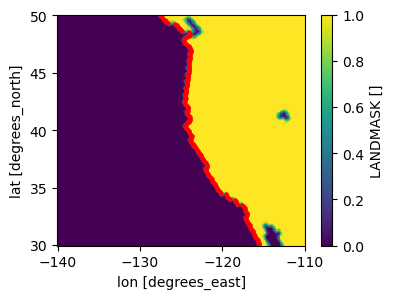

In [7]:
plot_landmask_and_coast(4, 3)

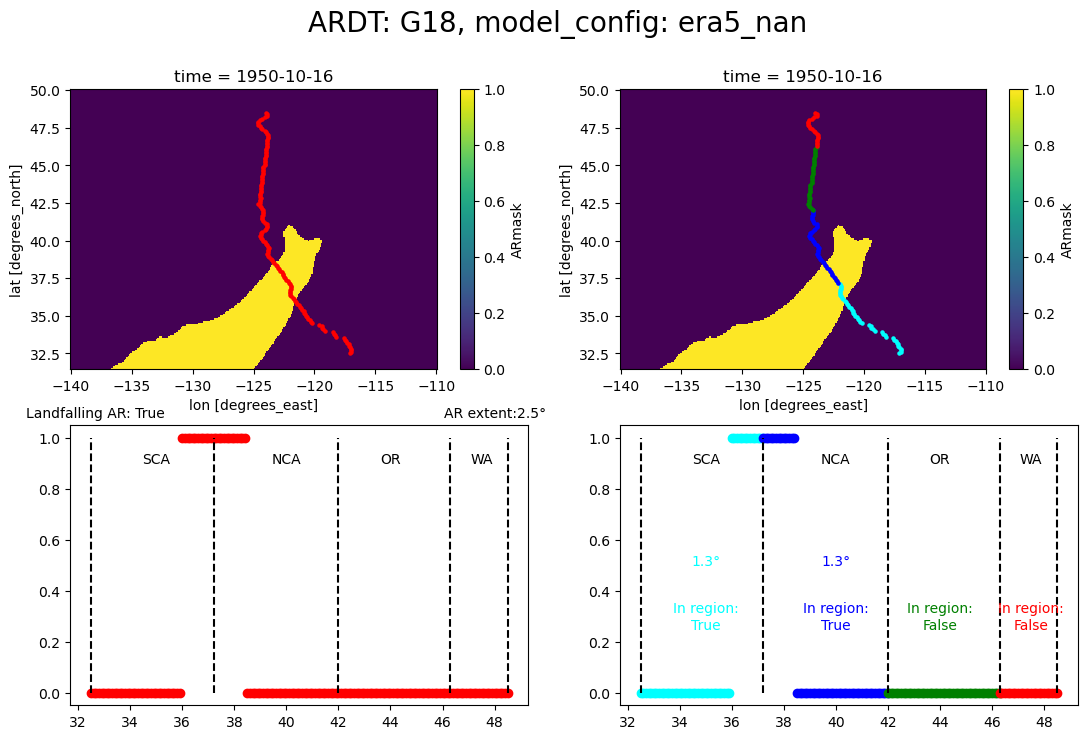

In [8]:
# Feel free to try different configurations here! Just make sure everything is consistent naming-wise.

tidx = 45 #365*46+147
model = 'era5'
member = 'nan'
ardt = 'G18'
plot_landfall(tidx, model, member, ardt)

In [9]:
# Pull the ARcoast era5 files
ARcoast_g18_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/G18/ARcoast.G18.era5.nan.nc', use_cftime=True)
ARcoast_te_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/TE/ARcoast.TE.era5.nan.nc', use_cftime=True)
ARcoast_tARget_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/tARget/ARcoast.tARget.era5.nan.nc', use_cftime=True)
# Pull the ARlandfall days for era5 files
ARlandfall_g18_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/G18/ARlandfall.G18.era5.nan.nc', use_cftime=True)
ARlandfall_te_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/TE/ARlandfall.TE.era5.nan.nc', use_cftime=True)
ARlandfall_tARget_era5 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/tARget/ARlandfall.tARget.era5.nan.nc', use_cftime=True)
# Remove nans and large negative values for tARget output
ARcoast_tARget_era5 = set_to_zero(ARcoast_tARget_era5)
ARlandfall_tARget_era5 = set_to_zero(ARlandfall_tARget_era5)
# Only keep the cold season AR days
ARcoast_g18_cold_era5 = ARcoast_g18_era5.where((ARcoast_g18_era5.time.dt.month >= 10) | (ARcoast_g18_era5.time.dt.month <= 3), drop=True)
ARcoast_te_cold_era5 = ARcoast_te_era5.where((ARcoast_te_era5.time.dt.month >= 10) | (ARcoast_te_era5.time.dt.month <= 3), drop=True)
ARcoast_tARget_cold_era5 = ARcoast_tARget_era5.where((ARcoast_tARget_era5.time.dt.month >= 10) | (ARcoast_tARget_era5.time.dt.month <= 3), drop=True)
# Only keep the cold season AR days
ARlandfall_g18_cold_era5 = ARlandfall_g18_era5.where((ARlandfall_g18_era5.time.dt.month >= 10) | (ARlandfall_g18_era5.time.dt.month <= 3), drop=True)
ARlandfall_te_cold_era5 = ARlandfall_te_era5.where((ARlandfall_te_era5.time.dt.month >= 10) | (ARlandfall_te_era5.time.dt.month <= 3), drop=True)
ARlandfall_tARget_cold_era5 = ARlandfall_tARget_era5.where((ARlandfall_tARget_era5.time.dt.month >= 10) | (ARlandfall_tARget_era5.time.dt.month <= 3), drop=True)
# Grab AR Days
ARlandfall_g18_cold_era5_times = ARlandfall_g18_cold_era5.where(ARlandfall_g18_cold_era5.landfall_wus == 1, drop=True).time.values
ARlandfall_te_cold_era5_times = ARlandfall_te_cold_era5.where(ARlandfall_te_cold_era5.landfall_wus == 1, drop=True).time.values
ARlandfall_tARget_cold_era5_times = ARlandfall_tARget_cold_era5.where(ARlandfall_tARget_cold_era5.landfall_wus == 1, drop=True).time.values
# Get AR Day counts
ARlandfall_count_g18_era5 = ARcoast_g18_cold_era5.ARcoast.sel(time=ARlandfall_g18_cold_era5_times).sum(dim='time')
ARlandfall_count_te_era5 = ARcoast_te_cold_era5.ARcoast.sel(time=ARlandfall_te_cold_era5_times).sum(dim='time')
ARlandfall_count_tARget_era5 = ARcoast_tARget_cold_era5.ARcoast.sel(time=ARlandfall_tARget_cold_era5_times).sum(dim='time')

In [10]:
# Similar to the above slide, but for CMIP6 models. Also separate by time period.

cmip6_ARlandfall = xa.Dataset(
    coords=dict(lat=('lat', ARlandfall_count_g18_era5.lat.values), idx=('idx', np.arange(15)), time_period=('time_period', ["historical", "near-term", "end-of-century"]), ardt=('ardt', ['G18', 'TE', 'tARget'])),
    data_vars = dict(ARcounts=(['lat', 'idx', 'time_period', 'ardt'], np.zeros((len(ARlandfall_count_g18_era5.lat.values), 15, 3, 3))))
)

for i in wusd3.index:
    model = wusd3.loc[i, 'Model']
    member = wusd3.loc[i, 'Member']
    calendar = wusd3.loc[i, 'Calendar']

    ARcoast_g18 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/G18/ARcoast.G18.{model}.{member}.nc', use_cftime=True)
    ARcoast_te = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/TE/ARcoast.TE.{model}.{member}.nc', use_cftime=True)
    ARcoast_tARget = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/tARget/ARcoast.tARget.{model}.{member}.nc', use_cftime=True)
    
    ARlandfall_g18 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/G18/ARlandfall.G18.{model}.{member}.nc', use_cftime=True)
    ARlandfall_te = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/TE/ARlandfall.TE.{model}.{member}.nc', use_cftime=True)
    ARlandfall_tARget = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/tARget/ARlandfall.tARget.{model}.{member}.nc', use_cftime=True)
    
    ARcoast_tARget = set_to_zero(ARcoast_tARget)
    ARlandfall_tARget = set_to_zero(ARlandfall_tARget)

    for tp in ['historical', 'near-term', 'end-of-century']:
        print(f'{model}/{member}/{tp}')
        # Not every GCM has the same calendar; we account for that here.
        syear = 1980 if tp=='historical' else 2016 if tp=='near-term' else 2066 if tp=='end-of-century' else -9999
        eyear = 2014 if tp=='historical' else 2050 if tp=='near-term' else 2100 if tp=='end-of-century' else -9999
        sdate = cftime.datetime(syear, 9, 1, calendar=calendar)
        edate = cftime.datetime(eyear, 8, 31, calendar=calendar) if i < 14 else cftime.datetime(eyear, 8, 30, calendar=calendar)
        
        ARcoast_g18_sliced = ARcoast_g18.sel(time=slice(sdate,edate))
        ARcoast_te_sliced = ARcoast_te.sel(time=slice(sdate,edate))
        ARcoast_tARget_sliced = ARcoast_tARget.sel(time=slice(sdate,edate))
        
        ARlandfall_g18_sliced = ARlandfall_g18.sel(time=slice(sdate,edate))
        ARlandfall_te_sliced = ARlandfall_te.sel(time=slice(sdate,edate))
        ARlandfall_tARget_sliced = ARlandfall_tARget.sel(time=slice(sdate,edate))
    
        ARcoast_g18_cold = ARcoast_g18_sliced.where((ARcoast_g18_sliced.time.dt.month >= 10) | (ARcoast_g18_sliced.time.dt.month <= 3), drop=True)
        ARcoast_te_cold = ARcoast_te_sliced.where((ARcoast_te_sliced.time.dt.month >= 10) | (ARcoast_te_sliced.time.dt.month <= 3), drop=True)
        ARcoast_tARget_cold = ARcoast_tARget_sliced.where((ARcoast_tARget_sliced.time.dt.month >= 10) | (ARcoast_tARget_sliced.time.dt.month <= 3), drop=True)
        
        ARlandfall_g18_cold = ARlandfall_g18_sliced.where((ARlandfall_g18_sliced.time.dt.month >= 10) | (ARlandfall_g18_sliced.time.dt.month <= 3), drop=True)
        ARlandfall_te_cold = ARlandfall_te_sliced.where((ARlandfall_te_sliced.time.dt.month >= 10) | (ARlandfall_te_sliced.time.dt.month <= 3), drop=True)
        ARlandfall_tARget_cold = ARlandfall_tARget_sliced.where((ARlandfall_tARget_sliced.time.dt.month >= 10) | (ARlandfall_tARget_sliced.time.dt.month <= 3), drop=True)
        
        ARlandfall_g18_cold_times = ARlandfall_g18_cold.where(ARlandfall_g18_cold.landfall_wus == 1, drop=True).time.values
        ARlandfall_te_cold_times = ARlandfall_te_cold.where(ARlandfall_te_cold.landfall_wus == 1, drop=True).time.values
        ARlandfall_tARget_cold_times = ARlandfall_tARget_cold.where(ARlandfall_tARget_cold.landfall_wus == 1, drop=True).time.values
        
        ARlandfall_count_g18 = ARcoast_g18_cold.ARcoast.sel(time=ARlandfall_g18_cold_times).sum(dim='time')
        ARlandfall_count_te = ARcoast_te_cold.ARcoast.sel(time=ARlandfall_te_cold_times).sum(dim='time')
        ARlandfall_count_tARget = ARcoast_tARget_cold.ARcoast.sel(time=ARlandfall_tARget_cold_times).sum(dim='time')

        # Standardize AR Day counts to per cold season per model
        cmip6_ARlandfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'G18'}] = (ARlandfall_count_g18/34)
        cmip6_ARlandfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'TE'}] = (ARlandfall_count_te/34)
        cmip6_ARlandfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'tARget'}] = (ARlandfall_count_tARget/34)

access-cm2/r5i1p1f1/historical
access-cm2/r5i1p1f1/near-term
access-cm2/r5i1p1f1/end-of-century
canesm5/r1i1p2f1/historical
canesm5/r1i1p2f1/near-term
canesm5/r1i1p2f1/end-of-century
cesm2/r11i1p1f1/historical
cesm2/r11i1p1f1/near-term
cesm2/r11i1p1f1/end-of-century
cnrm-esm2-1/r1i1p1f2/historical
cnrm-esm2-1/r1i1p1f2/near-term
cnrm-esm2-1/r1i1p1f2/end-of-century
ec-earth3/r1i1p1f1/historical
ec-earth3/r1i1p1f1/near-term
ec-earth3/r1i1p1f1/end-of-century
ec-earth3-veg/r1i1p1f1/historical
ec-earth3-veg/r1i1p1f1/near-term
ec-earth3-veg/r1i1p1f1/end-of-century
fgoals-g3/r1i1p1f1/historical
fgoals-g3/r1i1p1f1/near-term
fgoals-g3/r1i1p1f1/end-of-century
giss-e2-1-g/r1i1p1f2/historical
giss-e2-1-g/r1i1p1f2/near-term
giss-e2-1-g/r1i1p1f2/end-of-century
miroc6/r1i1p1f1/historical
miroc6/r1i1p1f1/near-term
miroc6/r1i1p1f1/end-of-century
mpi-esm1-2-hr/r3i1p1f1/historical
mpi-esm1-2-hr/r3i1p1f1/near-term
mpi-esm1-2-hr/r3i1p1f1/end-of-century
mpi-esm1-2-hr/r7i1p1f1/historical
mpi-esm1-2-hr/r7i1p1f

In [11]:
# Similar to above slide, but for CESM2-LE

cesm2le_ARlandfall = xa.Dataset(
    coords=dict(lat=('lat', ARlandfall_count_g18_era5.lat.values), idx=('idx', np.arange(10)), time_period=('time_period', ["historical", "near-term", "end-of-century"]), ardt=('ardt', ['G18', 'TE', 'tARget'])),
    data_vars = dict(ARcounts=(['lat', 'idx', 'time_period', 'ardt'], np.zeros((len(ARlandfall_count_g18_era5.lat.values), 10, 3, 3))))
)

for i in range(10):
    model = 'cesm2-le'
    member = str(1011+i*20)
    calendar = '365_day'

    ARcoast_g18 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/G18/ARcoast.G18.{model}.{member}.nc', use_cftime=True)
    ARcoast_te = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/TE/ARcoast.TE.{model}.{member}.nc', use_cftime=True)
    ARcoast_tARget = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARcoast/tARget/ARcoast.tARget.{model}.{member}.nc', use_cftime=True)
    
    ARlandfall_g18 = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/G18/ARlandfall.G18.{model}.{member}.nc', use_cftime=True)
    ARlandfall_te = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/TE/ARlandfall.TE.{model}.{member}.nc', use_cftime=True)
    ARlandfall_tARget = xa.open_dataset(f'/glade/work/tcorrie/ARdata/ARlandfall/tARget/ARlandfall.tARget.{model}.{member}.nc', use_cftime=True)
    
    ARcoast_tARget = set_to_zero(ARcoast_tARget)
    ARlandfall_tARget = set_to_zero(ARlandfall_tARget)

    for tp in ['historical', 'near-term', 'end-of-century']:
        print(f'{model}/{member}/{tp}')
        syear = 1980 if tp=='historical' else 2016 if tp=='near-term' else 2066 if tp=='end-of-century' else -9999
        eyear = 2014 if tp=='historical' else 2050 if tp=='near-term' else 2100 if tp=='end-of-century' else -9999
        sdate = cftime.datetime(syear, 9, 1, calendar=calendar)
        edate = cftime.datetime(eyear, 8, 31, calendar=calendar)
        
        ARcoast_g18_sliced = ARcoast_g18.sel(time=slice(sdate,edate))
        ARcoast_te_sliced = ARcoast_te.sel(time=slice(sdate,edate))
        ARcoast_tARget_sliced = ARcoast_tARget.sel(time=slice(sdate,edate))
        
        ARlandfall_g18_sliced = ARlandfall_g18.sel(time=slice(sdate,edate))
        ARlandfall_te_sliced = ARlandfall_te.sel(time=slice(sdate,edate))
        ARlandfall_tARget_sliced = ARlandfall_tARget.sel(time=slice(sdate,edate))
    
        ARcoast_g18_cold = ARcoast_g18_sliced.where((ARcoast_g18_sliced.time.dt.month >= 10) | (ARcoast_g18_sliced.time.dt.month <= 3), drop=True)
        ARcoast_te_cold = ARcoast_te_sliced.where((ARcoast_te_sliced.time.dt.month >= 10) | (ARcoast_te_sliced.time.dt.month <= 3), drop=True)
        ARcoast_tARget_cold = ARcoast_tARget_sliced.where((ARcoast_tARget_sliced.time.dt.month >= 10) | (ARcoast_tARget_sliced.time.dt.month <= 3), drop=True)
        
        ARlandfall_g18_cold = ARlandfall_g18_sliced.where((ARlandfall_g18_sliced.time.dt.month >= 10) | (ARlandfall_g18_sliced.time.dt.month <= 3), drop=True)
        ARlandfall_te_cold = ARlandfall_te_sliced.where((ARlandfall_te_sliced.time.dt.month >= 10) | (ARlandfall_te_sliced.time.dt.month <= 3), drop=True)
        ARlandfall_tARget_cold = ARlandfall_tARget_sliced.where((ARlandfall_tARget_sliced.time.dt.month >= 10) | (ARlandfall_tARget_sliced.time.dt.month <= 3), drop=True)
        
        ARlandfall_g18_cold_times = ARlandfall_g18_cold.where(ARlandfall_g18_cold.landfall_wus == 1, drop=True).time.values
        ARlandfall_te_cold_times = ARlandfall_te_cold.where(ARlandfall_te_cold.landfall_wus == 1, drop=True).time.values
        ARlandfall_tARget_cold_times = ARlandfall_tARget_cold.where(ARlandfall_tARget_cold.landfall_wus == 1, drop=True).time.values
        
        ARlandfall_count_g18 = ARcoast_g18_cold.ARcoast.sel(time=ARlandfall_g18_cold_times).sum(dim='time')
        ARlandfall_count_te = ARcoast_te_cold.ARcoast.sel(time=ARlandfall_te_cold_times).sum(dim='time')
        ARlandfall_count_tARget = ARcoast_tARget_cold.ARcoast.sel(time=ARlandfall_tARget_cold_times).sum(dim='time')

        cesm2le_ARlandfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'G18'}] = (ARlandfall_count_g18/34)
        cesm2le_ARlandfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'TE'}] = (ARlandfall_count_te/34)
        cesm2le_ARlandfall.loc[{'idx': i, 'time_period': tp, 'ardt': 'tARget'}] = (ARlandfall_count_tARget/34)

cesm2-le/1011/historical
cesm2-le/1011/near-term
cesm2-le/1011/end-of-century
cesm2-le/1031/historical
cesm2-le/1031/near-term
cesm2-le/1031/end-of-century
cesm2-le/1051/historical
cesm2-le/1051/near-term
cesm2-le/1051/end-of-century
cesm2-le/1071/historical
cesm2-le/1071/near-term
cesm2-le/1071/end-of-century
cesm2-le/1091/historical
cesm2-le/1091/near-term
cesm2-le/1091/end-of-century
cesm2-le/1111/historical
cesm2-le/1111/near-term
cesm2-le/1111/end-of-century
cesm2-le/1131/historical
cesm2-le/1131/near-term
cesm2-le/1131/end-of-century
cesm2-le/1151/historical
cesm2-le/1151/near-term
cesm2-le/1151/end-of-century
cesm2-le/1171/historical
cesm2-le/1171/near-term
cesm2-le/1171/end-of-century
cesm2-le/1191/historical
cesm2-le/1191/near-term
cesm2-le/1191/end-of-century


Text(0.5, 1.0, 'cesm2le')

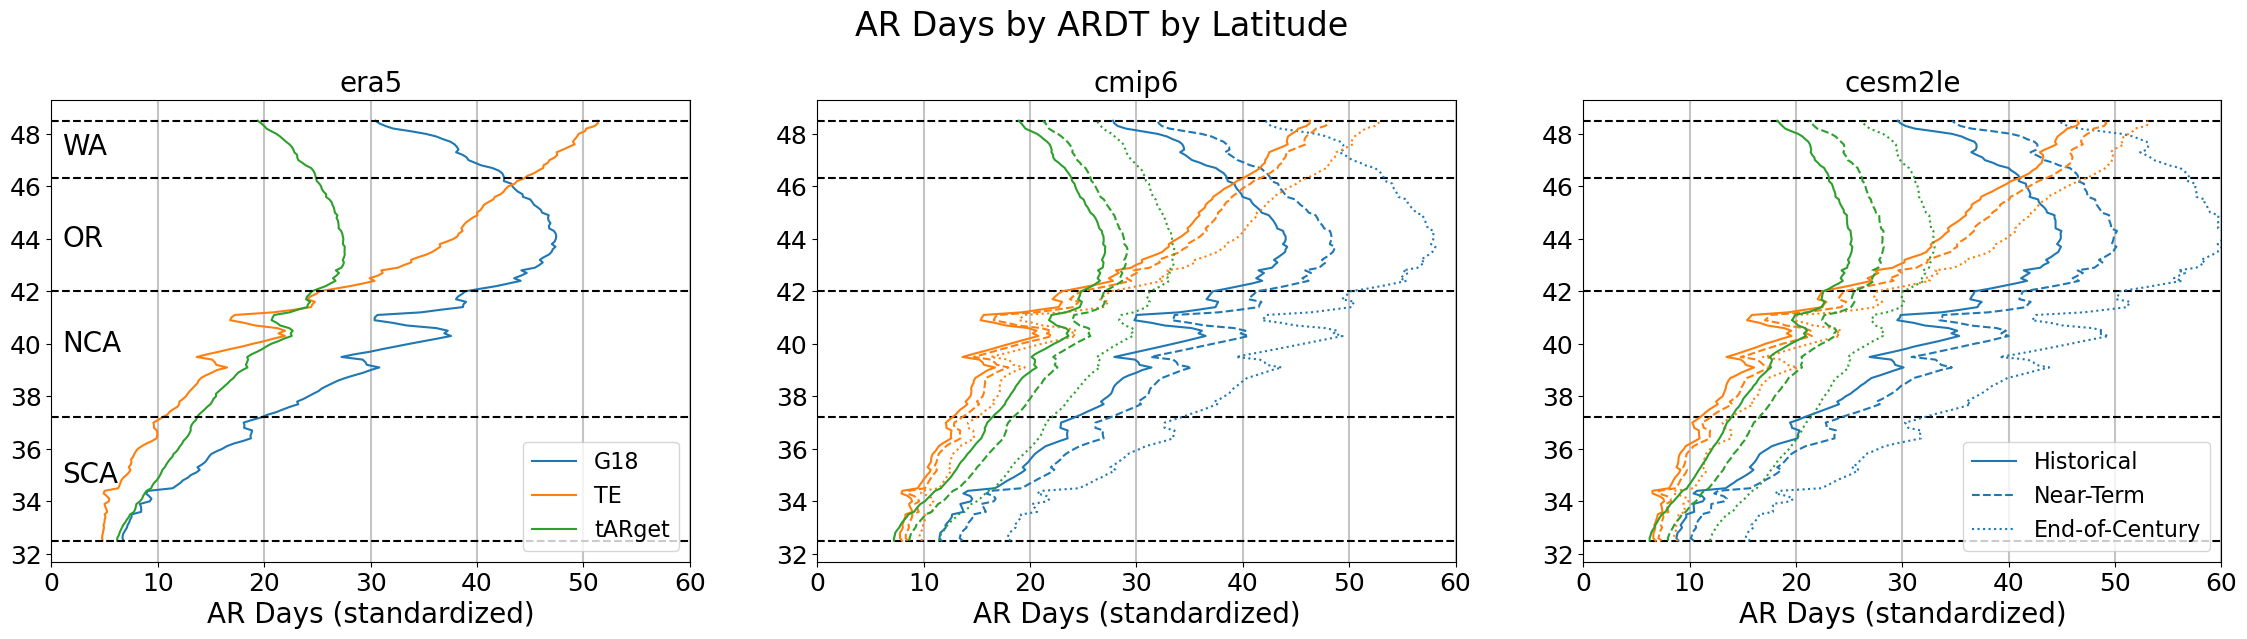

In [14]:
# Figure to plot the AR Day count by latitude bin.

f3, a3 = plt.subplots(1, 3, figsize=(28,6))

cmip6_means = cmip6_ARlandfall.ARcounts.mean(dim=['idx'])
cmip6_stds = cmip6_ARlandfall.ARcounts.std(dim=['idx']) # This doesn't end up being plotted; makes figure too noisy.

cesm2le_means = cesm2le_ARlandfall.ARcounts.mean(dim=['idx'])

# Standardize AR Day counts for era5
a3[0].plot(ARlandfall_count_g18_era5/75, ARlandfall_count_g18_era5.lat,  label='G18')
a3[0].plot(ARlandfall_count_te_era5/75, ARlandfall_count_te_era5.lat,  label='TE')
a3[0].plot(ARlandfall_count_tARget_era5/75, ARlandfall_count_tARget_era5.lat,  label='tARget')
f3.suptitle('AR Days by ARDT by Latitude', fontsize=24, y=1.03)
a3[0].set_title('era5', fontsize=20)

for i in range(3):
    a3[i].set_xlim(0,60)
    a3[i].grid(axis='x', which='major', linewidth=1.5, alpha=0.75)
    a3[i].hlines([32.5, 37.2, 42, 46.3, 48.5], 0, 60, linestyle='dashed', colors='k')
    a3[i].set_xlabel('AR Days (standardized)', fontsize=20)
a3[0].legend(loc='lower right', fontsize=16)

a3[0].text(1, 35, 'SCA', ha='left', va='center', fontsize=20)
a3[0].text(1, 40, 'NCA', ha='left', va='center', fontsize=20)
a3[0].text(1, 44, 'OR', ha='left', va='center', fontsize=20)
a3[0].text(1, 47.5, 'WA', ha='left', va='center', fontsize=20)
for i in range(3):
    a3[i].tick_params(axis='both', labelsize=18)


a3[1].plot(cmip6_means.sel(time_period='historical', ardt='G18'), cmip6_ARlandfall.lat, color='C0', linestyle='solid')
a3[1].plot(cmip6_means.sel(time_period='near-term', ardt='G18'), cmip6_ARlandfall.lat, color='C0', linestyle='dashed')
a3[1].plot(cmip6_means.sel(time_period='end-of-century', ardt='G18'), cmip6_ARlandfall.lat, color='C0', linestyle='dotted')


a3[1].plot(cmip6_means.sel(time_period='historical', ardt='TE'), cmip6_ARlandfall.lat, color='C1', linestyle='solid')
a3[1].plot(cmip6_means.sel(time_period='near-term', ardt='TE'), cmip6_ARlandfall.lat, color='C1', linestyle='dashed')
a3[1].plot(cmip6_means.sel(time_period='end-of-century', ardt='TE'), cmip6_ARlandfall.lat, color='C1', linestyle='dotted')


a3[1].plot(cmip6_means.sel(time_period='historical', ardt='tARget'), cmip6_ARlandfall.lat, color='C2', linestyle='solid')
a3[1].plot(cmip6_means.sel(time_period='near-term', ardt='tARget'), cmip6_ARlandfall.lat, color='C2', linestyle='dashed')
a3[1].plot(cmip6_means.sel(time_period='end-of-century', ardt='tARget'), cmip6_ARlandfall.lat, color='C2', linestyle='dotted')


a3[2].plot(cesm2le_means.sel(time_period='historical', ardt='G18'), cesm2le_ARlandfall.lat, color='C0', linestyle='solid', label='Historical')
a3[2].plot(cesm2le_means.sel(time_period='near-term', ardt='G18'), cesm2le_ARlandfall.lat, color='C0', linestyle='dashed', label='Near-Term')
a3[2].plot(cesm2le_means.sel(time_period='end-of-century', ardt='G18'), cesm2le_ARlandfall.lat, color='C0', linestyle='dotted', label='End-of-Century')

a3[2].plot(cesm2le_means.sel(time_period='historical', ardt='TE'), cesm2le_ARlandfall.lat, color='C1', linestyle='solid')
a3[2].plot(cesm2le_means.sel(time_period='near-term', ardt='TE'), cesm2le_ARlandfall.lat, color='C1', linestyle='dashed')
a3[2].plot(cesm2le_means.sel(time_period='end-of-century', ardt='TE'), cesm2le_ARlandfall.lat, color='C1', linestyle='dotted')

a3[2].plot(cesm2le_means.sel(time_period='historical', ardt='tARget'), cesm2le_ARlandfall.lat, color='C2', linestyle='solid')
a3[2].plot(cesm2le_means.sel(time_period='near-term', ardt='tARget'), cesm2le_ARlandfall.lat, color='C2', linestyle='dashed')
a3[2].plot(cesm2le_means.sel(time_period='end-of-century', ardt='tARget'), cesm2le_ARlandfall.lat, color='C2', linestyle='dotted')
a3[2].legend(loc='lower right', fontsize=16)

a3[1].set_title('cmip6', fontsize=20)
a3[2].set_title('cesm2le', fontsize=20)

#land = xa.open_dataset('/glade/derecho/scratch/tcorrie/regrids/landmask_regridded.nc')
#coast = xa.where(land['LANDMASK'] >= 0.5, 1, 0).idxmax(dim='lon').sel(lat=slice(32.49, 48.51))

#land.LANDMASK.plot(ax=a3[0], add_colorbar=False)
#a3[0].scatter(coast, coast.lat, color='r', s=10)
#for i in range(4):
#    a3[i].set_ylim(32.0, 49)
#a3[0].hlines([48.5, 46.3, 42, 37.2, 32.5], -140, -110, 'k', 'dashed')
#a3[0].set_xlabel("Longitude (°W)", fontsize=20)
#a3[0].set_ylabel("Latitude (°N)", fontsize=20)

In [15]:
f3.savefig('/glade/work/tcorrie/ARdata/Figures/coldseason_arcounts_bylatitude.png', bbox_inches='tight', dpi=1200)
f3.savefig('/glade/work/tcorrie/ARdata/Figures/JoC/coldseason_arcounts_bylatitude.png', bbox_inches='tight', dpi=1200)